In [1]:
import os

os.chdir(r"D:\my projects\smart car park")

print("Current folder:")
print(os.getcwd())

print("\nProject files:")
print(os.listdir())

Current folder:
D:\my projects\smart car park

Project files:
['.vscode', 'backend', 'dataset', 'frontend', 'requirements file.txt', 'requirements.txt']


In [2]:
print("Dataset files:")
print(os.listdir("dataset"))

Dataset files:
['parking_data.csv', 'parking_data_backup.csv']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("dataset/parking_data.csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 26064
Columns: 13


In [5]:
display(df.head())

,date,time,area,total_slots,occupied_slots,free_slots,reserved_slots,maintenance_slots,occupancy_percentage,day_of_week,is_weekend,is_holiday,weather
0,2026-01-01,00:00:00,City Center,50,35,15,0,0,70.0,Thursday,0,0,Cloudy
1,2026-01-01,00:00:00,Mall,50,29,20,0,1,58.0,Thursday,0,0,Cloudy
2,2026-01-01,00:00:00,Theatre,50,26,21,3,0,52.0,Thursday,0,0,Cloudy
3,2026-01-01,00:30:00,City Center,50,39,11,0,0,78.0,Thursday,0,0,Cloudy
4,2026-01-01,00:30:00,Mall,50,30,20,0,0,60.0,Thursday,0,0,Cloudy


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26064 entries, 0 to 26063
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  26064 non-null  object 
 1   time                  26064 non-null  object 
 2   area                  26064 non-null  object 
 3   total_slots           26064 non-null  int64  
 4   occupied_slots        26064 non-null  int64  
 5   free_slots            26064 non-null  int64  
 6   reserved_slots        26064 non-null  int64  
 7   maintenance_slots     26064 non-null  int64  
 8   occupancy_percentage  26064 non-null  float64
 9   day_of_week           26064 non-null  object 
 10  is_weekend            26064 non-null  int64  
 11  is_holiday            26064 non-null  int64  
 12  weather               26064 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usage: 2.6+ MB


In [7]:
print(df.isnull().sum())

date                    0
time                    0
area                    0
total_slots             0
occupied_slots          0
free_slots              0
reserved_slots          0
maintenance_slots       0
occupancy_percentage    0
day_of_week             0
is_weekend              0
is_holiday              0
weather                 0
dtype: int64


In [8]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Start date: 2026-01-01
End date: 2026-06-30


In [9]:
print("Minimum free slots:", df["free_slots"].min())
print("Maximum free slots:", df["free_slots"].max())

print("\nZero free-slot records:")
print((df["free_slots"] == 0).sum())

Minimum free slots: 0
Maximum free slots: 39

Zero free-slot records:
2727


In [10]:
df["is_free"] = (df["free_slots"] > 0).astype(int)

In [11]:
print(df["is_free"].value_counts())

is_free
1    23337
0     2727
Name: count, dtype: int64


In [12]:
print("\nPercentage:")
print(df["is_free"].value_counts(normalize=True) * 100)


Percentage:
is_free
1    89.537293
0    10.462707
Name: proportion, dtype: float64


In [13]:
availability_by_area = pd.crosstab(
    df["area"],
    df["is_free"],
    normalize="index"
) * 100

display(availability_by_area)

is_free,0,1
area,,
City Center,18.634899,81.365101
Mall,10.543278,89.456722
Theatre,2.209945,97.790055


In [14]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].dtype)

datetime64[ns]


In [15]:
df["time"] = pd.to_datetime(
    df["time"],
    format="%H:%M:%S"
)

print(df["time"].dtype)

datetime64[ns]


In [16]:
df["hour"] = df["time"].dt.hour
df["minute"] = df["time"].dt.minute

display(
    df[["time", "hour", "minute"]].head(10)
)

,time,hour,minute
0,1900-01-01 00:00:00,0,0
1,1900-01-01 00:00:00,0,0
2,1900-01-01 00:00:00,0,0
3,1900-01-01 00:30:00,0,30
4,1900-01-01 00:30:00,0,30
5,1900-01-01 00:30:00,0,30
6,1900-01-01 01:00:00,1,0
7,1900-01-01 01:00:00,1,0
8,1900-01-01 01:00:00,1,0
9,1900-01-01 01:30:00,1,30


In [17]:
df["month"] = df["date"].dt.month

display(
    df[["date", "month"]].head()
)

,date,month
0,2026-01-01,1
1,2026-01-01,1
2,2026-01-01,1
3,2026-01-01,1
4,2026-01-01,1


In [18]:
df = df.sort_values(
    ["date", "time"]
).reset_index(drop=True)

display(
    df[["date", "time", "area", "is_free"]].head()
)

,date,time,area,is_free
0,2026-01-01,1900-01-01 00:00:00,City Center,1
1,2026-01-01,1900-01-01 00:00:00,Mall,1
2,2026-01-01,1900-01-01 00:00:00,Theatre,1
3,2026-01-01,1900-01-01 00:30:00,City Center,1
4,2026-01-01,1900-01-01 00:30:00,Mall,1


In [19]:
unique_dates = sorted(
    df["date"].dt.date.unique()
)

split_index = int(len(unique_dates) * 0.8)

train_dates = unique_dates[:split_index]
test_dates = unique_dates[split_index:]

print(
    "Training dates:",
    train_dates[0],
    "to",
    train_dates[-1]
)

print(
    "Testing dates:",
    test_dates[0],
    "to",
    test_dates[-1]
)

Training dates: 2026-01-01 to 2026-05-24
Testing dates: 2026-05-25 to 2026-06-30


In [20]:
features = [
    "hour",
    "minute",
    "area",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "weather",
    "month"
]

target = "is_free"

In [21]:
train_df = df[
    df["date"].dt.date.isin(train_dates)
]

test_df = df[
    df["date"].dt.date.isin(test_dates)
]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [22]:
print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (20736, 8)
y_train: (20736,)

Testing data:
X_test: (5328, 8)
y_test: (5328,)


In [23]:
print("Training target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training target:
is_free
1    18566
0     2170
Name: count, dtype: int64

Testing target:
is_free
1    4771
0     557
Name: count, dtype: int64


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [25]:
numeric_features = [
    "hour",
    "minute",
    "is_weekend",
    "is_holiday",
    "month"
]

categorical_features = [
    "area",
    "day_of_week",
    "weather"
]

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numeric_features
        )
    ]
)

In [27]:
model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=8,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [28]:
model.fit(
    X_train,
    y_train
)

print("Decision Tree training completed!")

Decision Tree training completed!


In [29]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [30]:
y_probability = model.predict_proba(X_test)

print(y_probability[:10])

[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


In [31]:
free_probability = y_probability[:, 1]

free_percentage = free_probability * 100

print(free_percentage[:20])

[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100.]


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [33]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)

Accuracy: 0.8263888888888888
Precision: 0.9875760649087221
Recall: 0.8163906937748899
F1 Score: 0.8938611589213998


In [34]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["FULL", "FREE"]
    )
)

              precision    recall  f1-score   support

        FULL       0.37      0.91      0.52       557
        FREE       0.99      0.82      0.89      4771

    accuracy                           0.83      5328
   macro avg       0.68      0.86      0.71      5328
weighted avg       0.92      0.83      0.86      5328



In [35]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 508   49]
 [ 876 3895]]


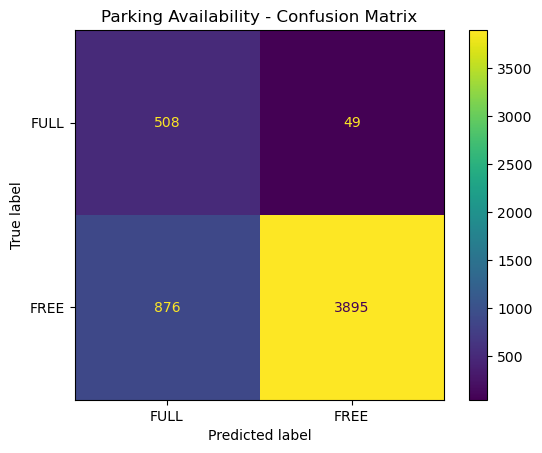

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FULL", "FREE"]
).plot()

plt.title("Parking Availability - Confusion Matrix")
plt.show()

In [37]:
results = test_df[
    [
        "date",
        "time",
        "area",
        "day_of_week",
        "weather",
        "free_slots",
        "is_free"
    ]
].copy()

results["predicted_is_free"] = y_pred

results["free_probability"] = free_percentage

results["predicted_percentage"] = (
    results["free_probability"]
).round(2)

display(results.head(20))

,date,time,area,day_of_week,weather,free_slots,is_free,predicted_is_free,free_probability,predicted_percentage
20736,2026-05-25,1900-01-01 00:00:00,City Center,Monday,Sunny,12,1,1,100.0,100.0
20737,2026-05-25,1900-01-01 00:00:00,Mall,Monday,Sunny,22,1,1,100.0,100.0
20738,2026-05-25,1900-01-01 00:00:00,Theatre,Monday,Sunny,20,1,1,100.0,100.0
20739,2026-05-25,1900-01-01 00:30:00,City Center,Monday,Sunny,19,1,1,100.0,100.0
20740,2026-05-25,1900-01-01 00:30:00,Mall,Monday,Sunny,24,1,1,100.0,100.0
20741,2026-05-25,1900-01-01 00:30:00,Theatre,Monday,Sunny,19,1,1,100.0,100.0
20742,2026-05-25,1900-01-01 01:00:00,City Center,Monday,Sunny,12,1,1,100.0,100.0
20743,2026-05-25,1900-01-01 01:00:00,Mall,Monday,Sunny,16,1,1,100.0,100.0
20744,2026-05-25,1900-01-01 01:00:00,Theatre,Monday,Sunny,24,1,1,100.0,100.0
20745,2026-05-25,1900-01-01 01:30:00,City Center,Monday,Sunny,20,1,1,100.0,100.0


In [38]:
new_prediction = pd.DataFrame({
    "hour": [18],
    "minute": [30],
    "area": ["City Center"],
    "day_of_week": ["Friday"],
    "is_weekend": [0],
    "is_holiday": [0],
    "weather": ["Sunny"],
    "month": [9]
})

In [39]:
prediction = model.predict(new_prediction)[0]

probability = model.predict_proba(
    new_prediction
)[0][1]

print("Prediction:", prediction)
print("Free probability:", round(probability * 100, 2), "%")

Prediction: 0
Free probability: 6.42 %


In [40]:
import joblib

In [41]:
os.makedirs("backend/ml/models", exist_ok=True)

In [42]:
joblib.dump(
    model,
    "backend/ml/models/parking_availability_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!
